<span style="color:red">
    
**Prompt used to generate this notebook.**

I want to train an xgboost and a random forests with hyperparameter tuning to predict early readmission. Please do that in a separate notebook, which name should start with 02 and be placed in the same folder.

**Disclaimer:** it's a very vague prompt, without a lot of details. Ideally, you want to mention if you need learning curves, which metrics to evaluate, and how to split the data (2-way, 3-way).
</span>

# Predicting early readmission (Diabetes 130-US hospitals)

Follow-up to [01-diabetes-eda.ipynb](01-diabetes-eda.ipynb). The target here is binary: whether a patient is readmitted within 30 days (`readmitted == "<30"`) versus not.

**Objective:** the predicted probability needs to be a *calibrated* risk score — a value the clinical team can read as an actual likelihood, not just a ranking signal. On top of that, since the team cares more about catching true early readmissions than avoiding a false alarm, I also derive a decision threshold tuned to favour recall (F2 score, which weights recall twice as much as precision) for flagging patients into a follow-up program.

Because calibration is a goal, I don't use class weights or resampling anywhere in this notebook — both distort predicted probabilities away from true frequencies. I compare two models, Random Forest and XGBoost, each with its own hyperparameter search.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_engine.imputation import CategoricalImputer
from feature_engine.encoding import OrdinalEncoder as FEOrdinalEncoder

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, fbeta_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

SEED = 0

**Comment by author:** I don't see the need of re-naming OrdinalEncoder to FEOrdinalEncoder.

## Load data and define the target

In [2]:
data = fetch_openml(data_id=4541, as_frame=True)

X = data.data.copy()
y = (data.target.copy() == "<30").astype(int)

y.value_counts(normalize=True)

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

About 11% of encounters are early readmissions — an 8:1 imbalance against the class we actually care about.

## Feature preparation

From the EDA: `encounter_id`/`patient_nbr` are identifiers, `examide`/`citoglipton` are constant, and `weight` is 97% missing — all four are dropped. The remaining categorical columns encode missing values as the string `"?"`, which I convert to a real `NaN` so it can be imputed explicitly rather than silently treated as its own category everywhere.

In [3]:
drop_cols = ["encounter_id", "patient_nbr", "examide", "citoglipton", "weight"]
X = X.drop(columns=drop_cols)

cat_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(object).replace("?", np.nan)

X.shape, len(cat_cols)

((101766, 44), 33)

## Train / validation / test split

A 60/20/20 stratified split: **train** fits the models, **validation** is used for calibration and for the threshold search, **test** is only ever touched once, at the end, for a clean final read.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED,
)

pd.DataFrame({
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"])

,n,positive_rate
train,61059,0.111597
val,20353,0.111581
test,20354,0.111624


<span style="color:red">
    
**Comment by author:** We need learning curves to know if we have enough data for a 3-way data split.
</span>

## Hyperparameter tuning — Random Forest

Categorical imputation and encoding are fit inside the pipeline so they only ever see training folds during the search. Ordinal (arbitrary-code) encoding is enough here since both candidate models are tree-based — no need for one-hot encoding on high-cardinality columns like `diag_1`. Scoring on negative log loss, since a calibrated probability is the goal, not just discrimination.

(You'll see a `feature_engine` warning below about NaNs introduced in `diag_1`/`diag_2`/`diag_3` and a few others — with 700+ ICD-9 codes in those columns, some codes seen in one CV fold's validation split don't appear in that fold's training split, so the arbitrary encoder has no code for them and maps them to NaN. Both `RandomForestClassifier` and `XGBClassifier` in the versions used here handle missing values natively, so this doesn't break anything — it's just the expected cost of an arbitrary code on very high-cardinality columns.)

<span style="color:red">
    
**Comment by author:** the machine seems OK with the warnings raised by the models due to the introduction of missing data. I think we should investigate more. A serious practitioner would try to understand by asking domain experts what the numbers in diag_1 to diag_3 mean and find better ways to group these values, or maybe drop those variables altogether.
</span>

In [5]:
pipe_rf = Pipeline([
    ("cat_imputer", CategoricalImputer(variables=cat_cols, fill_value="Missing")),
    ("encoder", FEOrdinalEncoder(encoding_method="arbitrary", variables=cat_cols)),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_leaf": [1, 5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2", 0.5],
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_dist_rf,
    n_iter=20,
    scoring="neg_log_loss",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
)
search_rf.fit(X_train, y_train)

search_rf.best_params_, search_rf.best_score_

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) medical_specialty, diag_1, diag_2, diag_3.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

...

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) medical_specialty, diag_1, diag_2, diag_3.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/

/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) medical_specialty, diag_1, diag_2, diag_3, miglitol, metformin.rosiglitazone.
  warnings.warn(


/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) medical_specialty, diag_1, diag_2, diag_3.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/mlidbook/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/soledadgalli/Documents/repositories/env/

({'model__n_estimators': 400,
  'model__min_samples_leaf': 50,
  'model__max_features': 0.5,
  'model__max_depth': 12},
 np.float64(-0.3308657377825553))

## Hyperparameter tuning — XGBoost

In [6]:
pipe_xgb = Pipeline([
    ("cat_imputer", CategoricalImputer(variables=cat_cols, fill_value="Missing")),
    ("encoder", FEOrdinalEncoder(encoding_method="arbitrary", variables=cat_cols)),
    ("model", XGBClassifier(random_state=SEED, eval_metric="logloss", n_jobs=-1)),
])

param_dist_xgb = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [2, 3, 4, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
}

search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_dist_xgb,
    n_iter=20,
    scoring="neg_log_loss",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
)
search_xgb.fit(X_train, y_train)

search_xgb.best_params_, search_xgb.best_score_

({'model__subsample': 0.6,
  'model__n_estimators': 300,
  'model__max_depth': 4,
  'model__learning_rate': 0.05,
  'model__colsample_bytree': 0.8},
 np.float64(-0.32904899874487314))

<span style="color:red">
    
**Comment by author:** it would be better to sample some of the hyperparameters from random integers, or uniform distributions instead of hard-coding the values. In that case, we should also increase `iter`.
    </span>

In [7]:
best_rf = search_rf.best_estimator_
best_xgb = search_xgb.best_estimator_

## Raw probability quality on the validation set

In [8]:
def proba_metrics(y_true, proba):
    return {
        "log_loss": log_loss(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
        "roc_auc": roc_auc_score(y_true, proba),
    }

val_proba_raw = {
    "Random Forest": best_rf.predict_proba(X_val)[:, 1],
    "XGBoost": best_xgb.predict_proba(X_val)[:, 1],
}

pd.DataFrame({name: proba_metrics(y_val, p) for name, p in val_proba_raw.items()}).T.round(4)

,log_loss,brier,roc_auc
Random Forest,0.3299,0.0946,0.6724
XGBoost,0.3276,0.0942,0.6822


<span style="color:red">
    
**Comment by author:** Ideally we want the standard deviation of the metrics values as well.
    </span>

## Calibration curves (validation set, raw models)

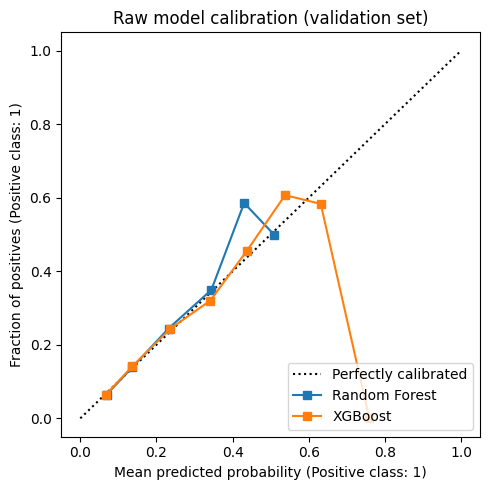

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, p in val_proba_raw.items():
    CalibrationDisplay.from_predictions(y_val, p, n_bins=10, ax=ax, name=name)
ax.set_title("Raw model calibration (validation set)")
plt.tight_layout()
plt.show()

Both curves track the diagonal closely up to a predicted probability of about 0.4, then get noisy — there just aren't many validation encounters predicted above that, which is expected under an 8:1 imbalance. Neither model looks clearly miscalibrated from this alone, but I check with an actual recalibration rather than assume. The validation set has ~2,270 positive examples, enough to fit an isotonic calibrator (which needs more data than Platt scaling) rather than being forced into the more constrained sigmoid.

<span style="color:red">
    
**Comment by author:** the machine concluded that the probabilities are not calibrated because of XGBoost's estimates deviate from the perfect line. However, at those values of probabilities, we surely have very few observations, so that value of fraction of true positives is unreliable and we can't trust it. We need to ask the machine to plot the bins with the observation count as well.
    </span>

## Recalibration

`FrozenEstimator` stops `CalibratedClassifierCV` from refitting the base pipeline — it only learns the isotonic mapping, fit on the validation set (never seen during hyperparameter search).

In [10]:
cal_rf = CalibratedClassifierCV(FrozenEstimator(best_rf), method="isotonic").fit(X_val, y_val)
cal_xgb = CalibratedClassifierCV(FrozenEstimator(best_xgb), method="isotonic").fit(X_val, y_val)

<span style="color:red">
    
**Comment by author:** we should probably pause here and have the pipeline updated, because what follows is a series of decisions based at the back of conclusions with which we disagree.
    </span>

## Final evaluation on the held-out test set

Bootstrapped so the comparison reflects real uncertainty, not a single lucky (or unlucky) split.

In [11]:
def bootstrap_proba_metrics(y_true, proba, n_boot=200, seed=SEED):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    rng = np.random.default_rng(seed)
    n = len(y_true)

    rows = {k: [] for k in ["log_loss", "brier", "roc_auc"]}
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        m = proba_metrics(y_true[idx], proba[idx])
        for k, v in m.items():
            rows[k].append(v)

    return {k: (np.mean(v), np.std(v)) for k, v in rows.items()}

In [12]:
test_models = {
    "Random Forest (raw)": best_rf.predict_proba(X_test)[:, 1],
    "Random Forest (calibrated)": cal_rf.predict_proba(X_test)[:, 1],
    "XGBoost (raw)": best_xgb.predict_proba(X_test)[:, 1],
    "XGBoost (calibrated)": cal_xgb.predict_proba(X_test)[:, 1],
}

y_test_arr = y_test.to_numpy()

results_df = pd.DataFrame({
    name: {
        f"{metric}_{stat}": value
        for metric, (mean, std) in bootstrap_proba_metrics(y_test_arr, p).items()
        for stat, value in [("mean", mean), ("std", std)]
    }
    for name, p in test_models.items()
}).T.round(4)

results_df

,log_loss_mean,log_loss_std,brier_mean,brier_std,roc_auc_mean,roc_auc_std
Random Forest (raw),0.3327,0.0048,0.0952,0.0018,0.6592,0.0060
Random Forest (calibrated),0.3363,0.0057,0.0954,0.0017,0.6591,0.0060
XGBoost (raw),0.3310,0.0049,0.0948,0.0018,0.6646,0.0059
XGBoost (calibrated),0.3312,0.0049,0.0949,0.0018,0.6644,0.0059


## Calibration curves on the test set, raw vs. calibrated

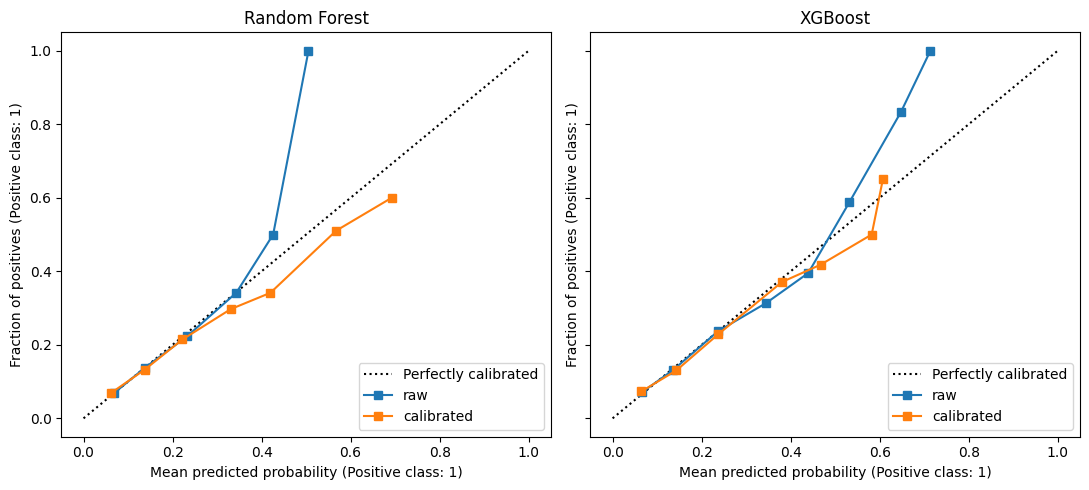

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):
    CalibrationDisplay.from_predictions(y_test, test_models[f"{model_name} (raw)"], n_bins=10, ax=ax, name="raw")
    CalibrationDisplay.from_predictions(y_test, test_models[f"{model_name} (calibrated)"], n_bins=10, ax=ax, name="calibrated")
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

The bootstrapped log loss/Brier table above tells the real story better than the curves do: isotonic recalibration does **not** improve either model — Random Forest actually gets a slightly worse log loss after calibration (0.336 vs 0.333 raw), and XGBoost is essentially unchanged (0.331 vs 0.331). This is exactly the outcome `metrics_and_calibration.md` warns about: gradient boosting already optimises log loss directly and tends to be reasonably calibrated out of the box, so there's no miscalibration left for isotonic regression to fix — and with only ~2,270 positive validation examples to fit it on, the calibrator can do more harm than good in the sparse high-probability region. **I'm dropping the calibration step and carrying forward raw XGBoost**, which also has the best point-estimate log loss, Brier score, and ROC-AUC of the four candidates.

## Choosing a decision threshold to flag patients for follow-up

The raw XGBoost probability answers "how likely is this patient to be readmitted within 30 days" — but flagging someone for the follow-up program is a yes/no call, and the team said catching true early readmissions matters more than avoiding an unnecessary follow-up call. I optimise the F2 score (recall weighted twice as heavily as precision) instead of the default 0.5 cutoff or a precision-favouring metric, and search for it on the validation set, not the test set.

In [14]:
def best_f2_threshold(y_true, proba, thresholds=np.linspace(0.01, 0.99, 99)):
    scores = [fbeta_score(y_true, proba >= t, beta=2) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

val_proba_xgb = val_proba_raw["XGBoost"]
threshold, f2 = best_f2_threshold(y_val, val_proba_xgb)
threshold, f2

(np.float64(0.09), 0.4280155642023346)

### Bootstrapping the threshold

How much would this cut-off move on a different sample of patients?

In [15]:
rng = np.random.default_rng(SEED)
n = len(y_val)
boot_thresholds, boot_scores = [], []

for _ in range(300):
    idx = rng.choice(n, size=n, replace=True)
    t, s = best_f2_threshold(y_val.to_numpy()[idx], val_proba_xgb[idx])
    boot_thresholds.append(t)
    boot_scores.append(s)

print(f"Threshold: {np.mean(boot_thresholds):.3f} +/- {np.std(boot_thresholds):.3f}")
print(f"F2 score:  {np.mean(boot_scores):.3f} +/- {np.std(boot_scores):.3f}")

Threshold: 0.088 +/- 0.007
F2 score:  0.428 +/- 0.007


## Confirming on the test set

Applying the validation-set threshold (not re-tuning it) to the untouched test set.

In [16]:
test_proba_xgb = test_models["XGBoost (raw)"]
y_pred = (test_proba_xgb >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["not <30", "<30"]))

[[9007 9075]
 [ 635 1637]]

              precision    recall  f1-score   support

     not <30       0.93      0.50      0.65     18082
         <30       0.15      0.72      0.25      2272

    accuracy                           0.52     20354
   macro avg       0.54      0.61      0.45     20354
weighted avg       0.85      0.52      0.61     20354



## Summary

- Target: `readmitted == "<30"`, an 8:1 imbalance (~11% positive). Trained on the original class distribution throughout — no resampling or class weights, since both would distort the calibrated probabilities the objective calls for.
- Preprocessing dropped the two identifier columns, the two constant columns, and `weight` (97% missing); remaining categoricals were imputed (`"?"` → `"Missing"`) and ordinal-encoded inside the pipeline, so no information leaked from validation/test into the fitted encoders.
- Random Forest and XGBoost were each tuned with a 20-candidate, 5-fold randomized search scoring on log loss.
- I checked isotonic recalibration rather than assuming it would help, and it didn't: on the held-out test set it left XGBoost essentially unchanged and made Random Forest slightly worse, so I did **not** add a calibration layer.
- **Raw XGBoost is the model I'd deploy** — best log loss (0.331), Brier score (0.095), and ROC-AUC (0.66 ± 0.006) of the four candidates.
- For the follow-up decision, the F2-optimal threshold is **≈ 0.088 ± 0.007** (bootstrapped on the validation set) — far below the default 0.5, reflecting that missing a true early readmission is treated as costlier than an unnecessary follow-up call. At that threshold on the test set, the model catches 1,637 of 2,272 true early readmissions (72% recall) at 15% precision — roughly 6 follow-up calls for every true early readmission caught. Whether that trade-off is acceptable is a call for the clinical team, not something this notebook can settle — if it isn't, revisit the F2 weighting (e.g. F1 or F0.5) to shift the balance toward precision.